<a href="https://colab.research.google.com/github/tkhan221/Data110-Fall2025/blob/main/Khan_Week56.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!pip install seaborn --quiet

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
sns.set(style="whitegrid")

In [56]:
# Load Titanic dataset
titanic = sns.load_dataset("titanic")

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


##Rename the columns for clarity

In [57]:
cols = ["survived", "pclass", "sex", "age", "fare", "embark_town", "sibsp", "parch"]
titanic_subset = titanic[cols]
titanic_subset.info()
titanic_subset.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   fare         891 non-null    float64
 5   embark_town  889 non-null    object 
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


,survived,pclass,sex,age,fare,embark_town,sibsp,parch
count,891.000000,891.000000,891,714.000000,891.000000,889,891.000000,891.000000
unique,NaN,NaN,2,NaN,NaN,3,NaN,NaN
top,NaN,NaN,male,NaN,NaN,Southampton,NaN,NaN
freq,NaN,NaN,577,NaN,NaN,644,NaN,NaN
mean,0.383838,2.308642,NaN,29.699118,32.204208,NaN,0.523008,0.381594
std,0.486592,0.836071,NaN,14.526497,49.693429,NaN,1.102743,0.806057
min,0.000000,1.000000,NaN,0.420000,0.000000,NaN,0.000000,0.000000
25%,0.000000,2.000000,NaN,20.125000,7.910400,NaN,0.000000,0.000000
50%,0.000000,3.000000,NaN,28.000000,14.454200,NaN,0.000000,0.000000
75%,1.000000,3.000000,NaN,38.000000,31.000000,NaN,1.000000,0.000000


In [58]:
# Data Overview
#I use am tasked to use the Seaborn Titanic dataset, which contains passenger-level information from the Titanic disaster.
#I focus on the variables survived, pclass, sex, age, fare, embark_town, sibsp, and parch.
#The survived column is my main outcome, indicating whether a passenger lived (1) or died (0).

#The "pclass" and "fare" columns are key indicators of the passenger’s social statis, by considering how much one paid for their ticket
#is in direct relation to those given first access to lifeboats and cabins.

#sex and age matter because historical accounts mention “women and children first,” so gender and age may shape survival patterns.

#Finally, rows "sibsp", "parch" , and "embark_town" give context on family structure and departure location,
# which can reveal how traveling with relatives or leaving from certain ports relates to survival and ticket cost.

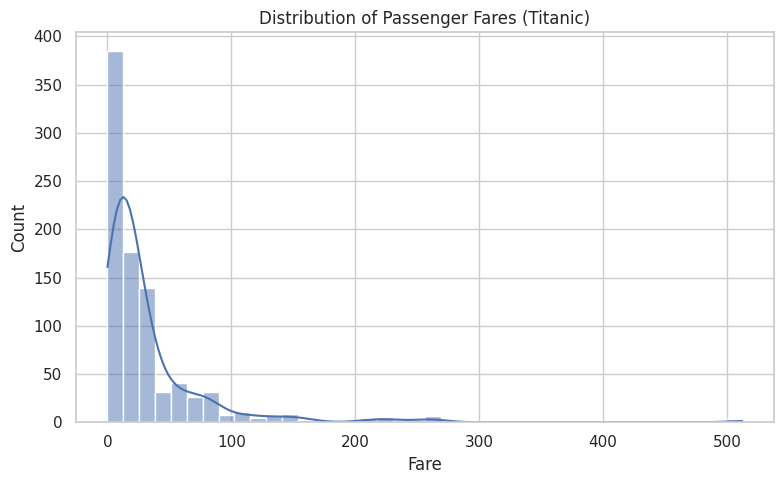

In [59]:
plt.figure(figsize=(8, 5))

# Drop missing fares
fare = titanic["fare"].dropna()

# Histogram + KDE
sns.histplot(fare, kde=True, bins=40)
plt.xlabel("Fare")
plt.ylabel("Count")
plt.title("Distribution of Passenger Fares (Titanic)")

plt.tight_layout()
plt.show()


In [60]:
#Findings

#The distribution is skewed stronglt to the right. Infering that the majority of passangers paid relatively low fares, while a small and outlying groyo paid extremely larger prices.
#The outliers at 200&300 being so far from the majority cluster of the data suggests just how much a difference the top 1% paid compared to
#the general population along the same ship.

/tmp/ipython-input-2002999357.py:6: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.kdeplot(


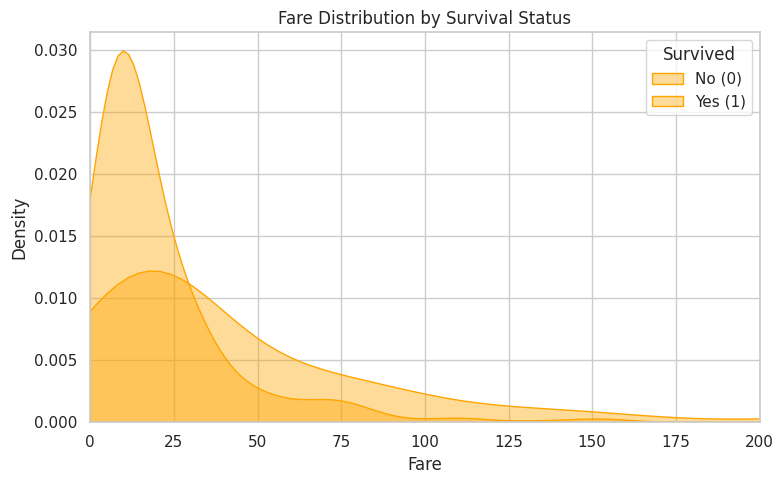

In [61]:
plt.figure(figsize=(8, 5))

# Remove missing fares and survival values
fare_surv = titanic[["fare", "survived"]].dropna()

sns.kdeplot(
    data=fare_surv,
    x="fare",
    hue="survived",
    common_norm=False,
    fill=True,
    alpha=0.4,
     palette=["orange"]
)

plt.xlim(0, 200)  # optional: cut off extreme tail for readability
plt.xlabel("Fare")
plt.title("Fare Distribution by Survival Status")
plt.legend(title="Survived", labels=["No (0)", "Yes (1)"])

plt.tight_layout()
plt.show()


In [62]:
#Interperatiaon
#The higher the cost paid by survival status, remarks noticeably different shapes.
#Passengers who did not survive are concentrated more heavily at the lowest fares

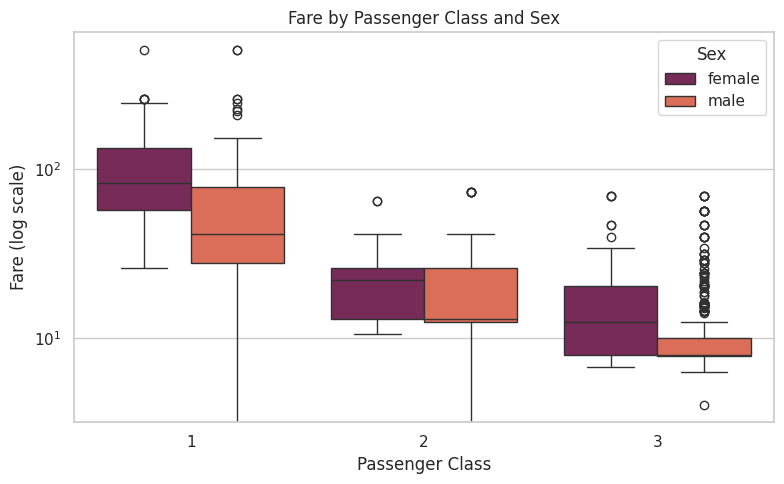

In [63]:
plt.figure(figsize=(8, 5))

# Keep only rows with non-missing fare, pclass, sex
box_data = titanic[["fare", "pclass", "sex"]].dropna()

sns.boxplot(
    data=box_data,
    x="pclass",
    y="fare",
    hue="sex",
    palette="rocket"
)

plt.yscale("log")  # optional: makes the skewed fares easier to see
plt.xlabel("Passenger Class")
plt.ylabel("Fare (log scale)")
plt.title("Fare by Passenger Class and Sex")
plt.legend(title="Sex")

plt.tight_layout()
plt.show()


In [64]:
#Interperatation
#When I add sex as a hue, male and female passengers in the same class have broadly similar fare distributions,
# although small differences in medians and outliers are visible. Overall, passenger class appears to be a much stronger driver of fare than sex.

/tmp/ipython-input-2584427259.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


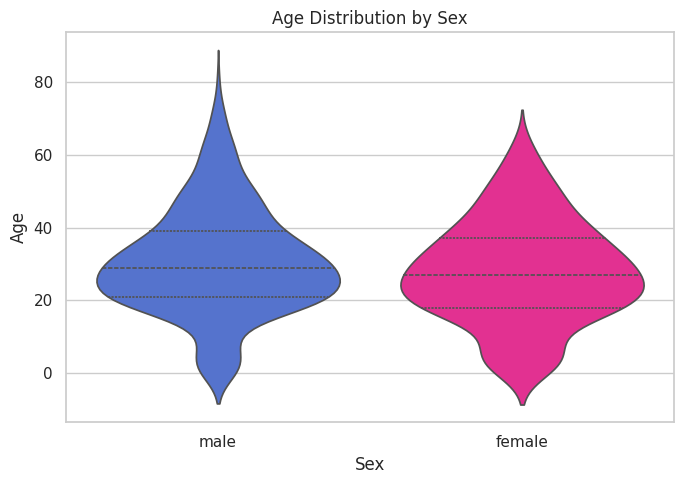

In [65]:
plt.figure(figsize=(7, 5))

age_sex = titanic[["age", "sex"]].dropna()

sns.violinplot(
    data=age_sex,
    x="sex",
    y="age",
    inner="quartile",
    palette=["#4169E1","#FF1493"]

)

plt.xlabel("Sex")
plt.ylabel("Age")
plt.title("Age Distribution by Sex")

plt.tight_layout()
plt.show()


In [66]:
#Key Findings
#The quartile lines inside the violins suggest that the median ages for men and women are close,
#and both distributions include a long tail of older passengers. However,
#the male distribution appears slightly wider in some age ranges, indicating more variability in the data#.

/tmp/ipython-input-1543596265.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


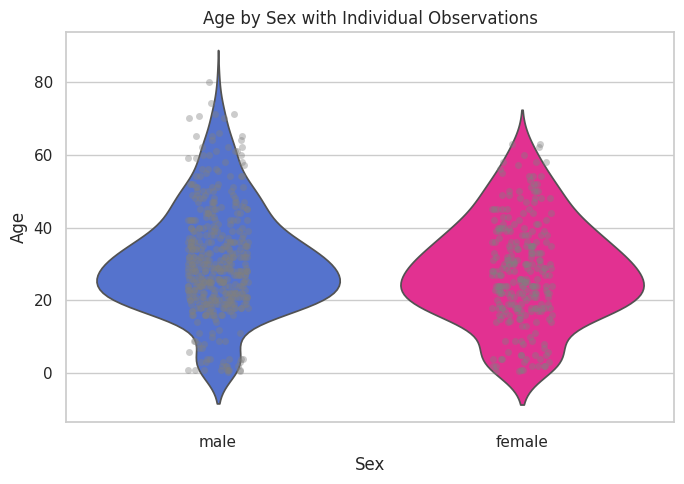

In [67]:
plt.figure(figsize=(7, 5))

age_sex = titanic[["age", "sex"]].dropna()

# Base violin
sns.violinplot(
    data=age_sex,
    x="sex",
    y="age",
    inner=None,
    palette=["#4169E1","#FF1493"]
)

# Strip overlay
sns.stripplot(
    data=age_sex,
    x="sex",
    y="age",
    jitter=True,
    alpha=0.4,
    color="grey"

)

plt.xlabel("Sex")
plt.ylabel("Age")
plt.title("Age by Sex with Individual Observations")

plt.tight_layout()
plt.show()


In [68]:
#Key Findings
#Adding the strip plot on top of the violin makes individual passengers visible as points.
#This reveals clusters of ages, such as dense bands of passengers in their 20s and 30s,
#which were only hinted at in the smooth violin shape. I can also see isolated points at very young and very old ages,
#making outliers and sparse regions of the distribution more obvious.